In [1]:
import numpy as np

import grover
import utils
import entropy
import quantum_random_walk as qrw
import mps
import qft

# Grover algorithm entropy analysis

In [2]:
shots=10240
qubits=8 # use 10 with caution
marked_state = 0b111  # target state as integer (|111> = 7)

In [3]:
# We test with applying Grover operator G k times and measure success probability
for k in range(1, 11):
    qc = grover.construct_grover(qubits, k, marked_state)
    counts = utils.measure(qc, shots,skip_qubits=[qubits])

    marked_bitstring = format(marked_state, f'0{qubits}b')
    success_counts = counts.get(marked_bitstring, 0)
    probability = success_counts / shots
    theta = np.arcsin(np.sqrt(1/2**qubits))
    prediction = np.sin((2*k+1)*theta)**2
    print(f"k={k:2d}  success state probability: {probability:.5f}   theoretical prediction: {prediction:.5f}")

k= 1  success state probability: 0.03467   theoretical prediction: 0.03479
k= 2  success state probability: 0.09463   theoretical prediction: 0.09464
k= 3  success state probability: 0.18438   theoretical prediction: 0.17972
k= 4  success state probability: 0.28574   theoretical prediction: 0.28474
k= 5  success state probability: 0.40039   theoretical prediction: 0.40317
k= 6  success state probability: 0.52783   theoretical prediction: 0.52762
k= 7  success state probability: 0.64014   theoretical prediction: 0.65035
k= 8  success state probability: 0.76270   theoretical prediction: 0.76372
k= 9  success state probability: 0.85820   theoretical prediction: 0.86068
k=10  success state probability: 0.93467   theoretical prediction: 0.93518


In [4]:
k_optimal = grover.optimal_iterations(qubits) 
print(f"optimal amount of repetitions: {k_optimal}")

qc = grover.construct_grover(qubits, k_optimal, marked_state=marked_state)
counts = utils.measure(qc, shots, skip_qubits=[qubits])

marked_bitstring = format(marked_state, f'0{qubits}b')
success_counts = counts.get(marked_bitstring, 0)
probability = success_counts / shots
theta = np.arcsin(np.sqrt(1/2**qubits))
prediction = np.sin((2*k_optimal+1)*theta)**2
print(f"k={k_optimal:2d}  success state probability: {probability:.5f}   theoretical prediction: {prediction:.5f}")


optimal amount of repetitions: 12
k=12  success state probability: 1.00000   theoretical prediction: 0.99995


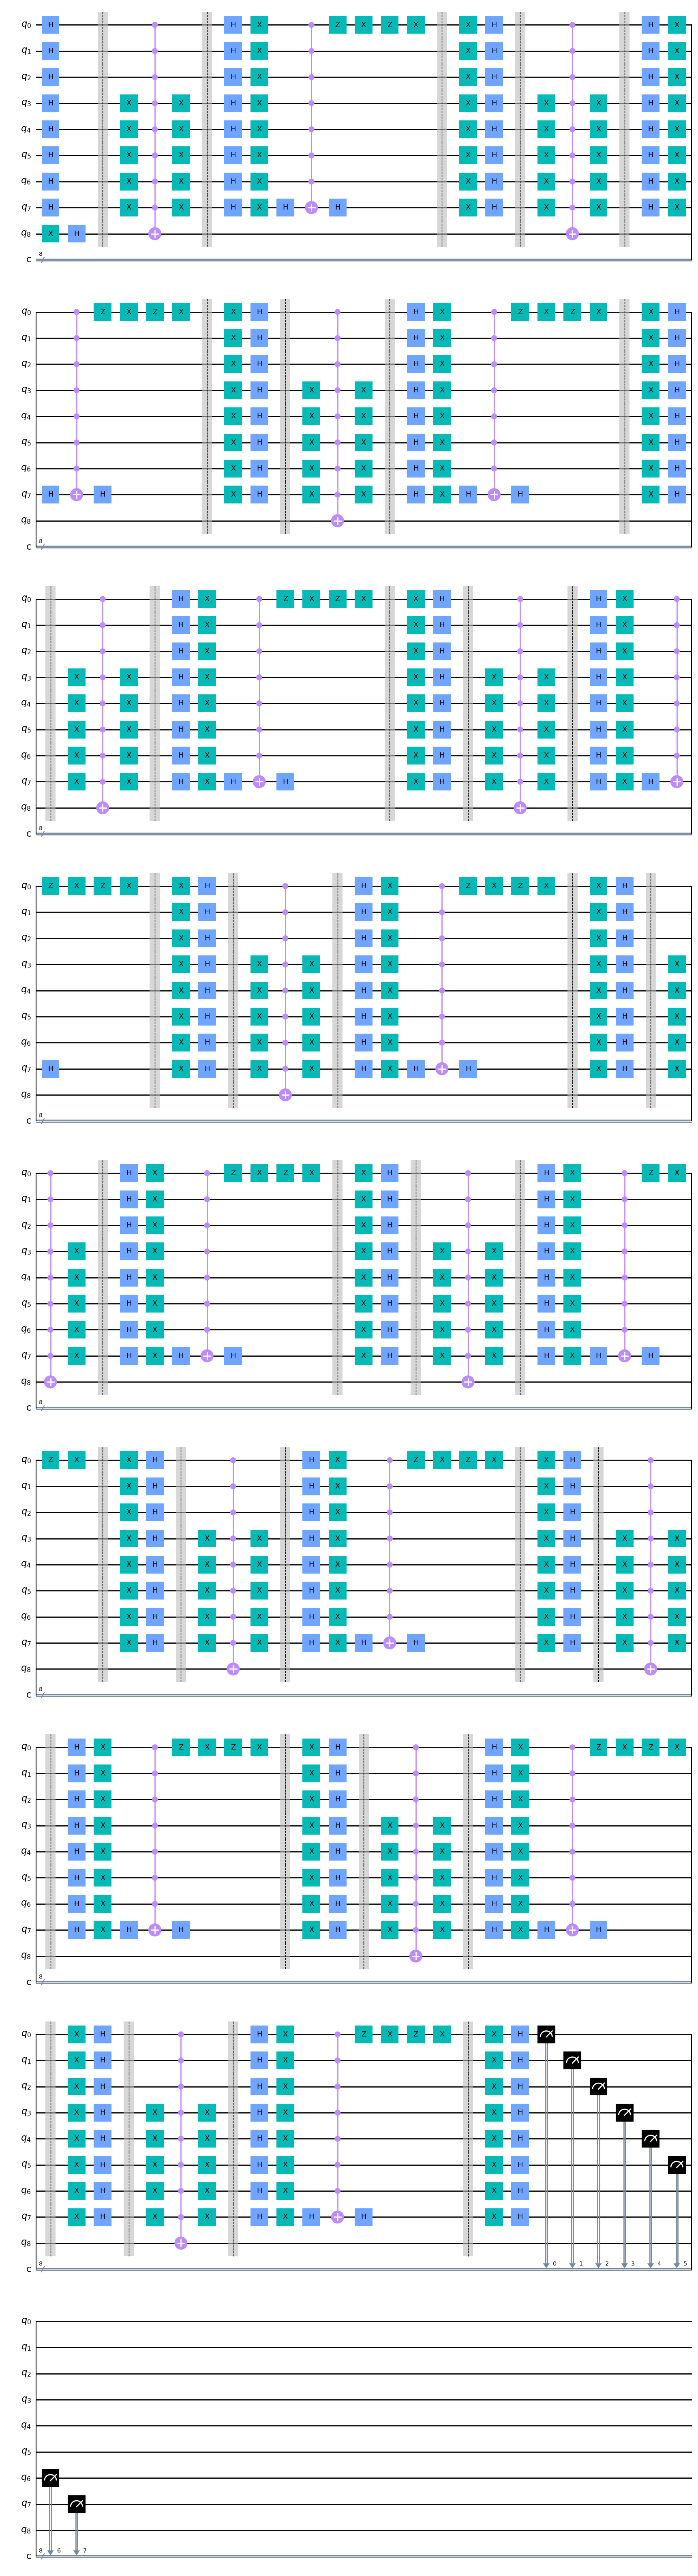

In [5]:
qc.draw(output="mpl",style="clifford")

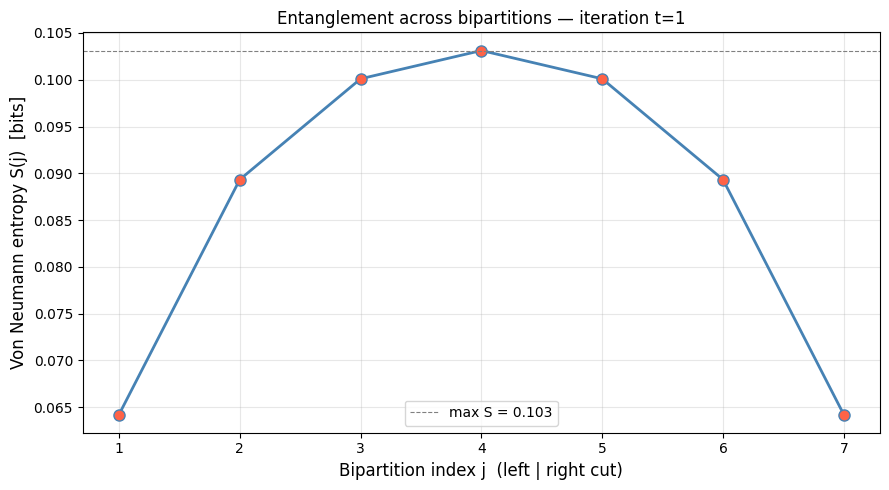

In [6]:
t_fixed = 1
qc = grover.construct_grover(qubits, k=t_fixed, marked_state=marked_state)
entropy.plot_entropy_vs_j(qc, n=qubits, t= t_fixed)

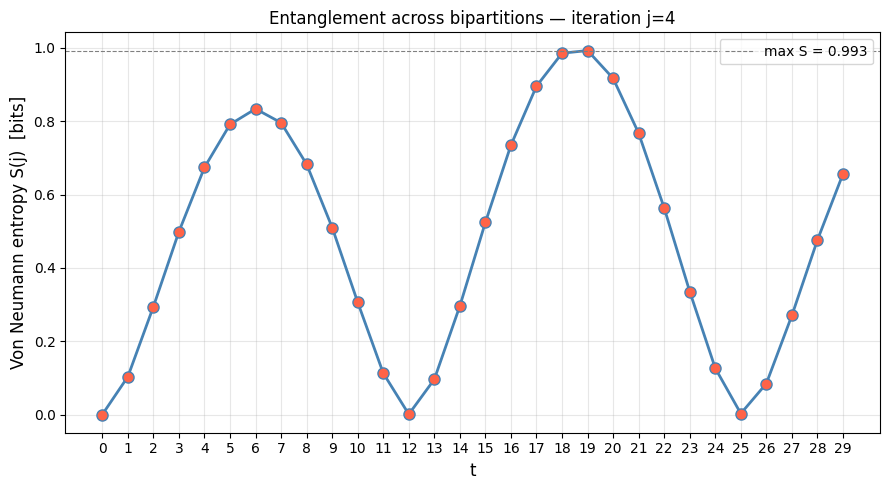

In [7]:
grover_lambda = lambda t: grover.construct_grover(qubits, t, marked_state=marked_state)
entropy.plot_entropy_vs_t(grover_lambda, n=qubits, j=qubits // 2, t_max=30)

n= 2  j=1  S=0.00000
n= 3  j=1  S=0.19794
n= 4  j=2  S=0.90234
n= 5  j=2  S=0.00685
n= 6  j=3  S=0.51978
n= 7  j=3  S=0.76242
n= 8  j=4  S=0.67392
n= 9  j=4  S=0.48063
n=10  j=5  S=0.31261
n=11  j=5  S=0.19050
n=12  j=6  S=0.11236


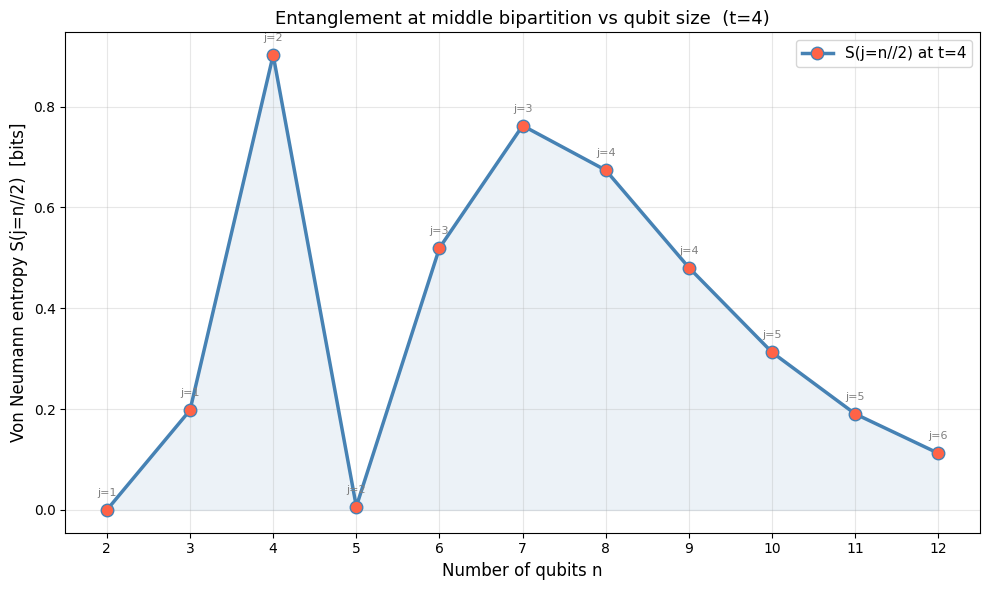

In [8]:
marked_state = 7
qubit_sizes  = list(range(2, 13))

# Single t
t_fixed  = 4
builder  = lambda n: grover.construct_grover(n, t_fixed, marked_state)
entropy.plot_entropy_vs_n(qubit_sizes, builder, t_fixed)


n= 2  j=1  S=0.00000
n= 3  j=1  S=0.28344
n= 4  j=2  S=0.42502
n= 5  j=2  S=0.35592
n= 6  j=3  S=0.26031
n= 7  j=3  S=0.16689
n= 8  j=4  S=0.10312
n= 9  j=4  S=0.06042
n=10  j=5  S=0.03482
n=11  j=5  S=0.01954
n=12  j=6  S=0.01086
n= 2  j=1  S=0.00000
n= 3  j=1  S=0.92453
n= 4  j=2  S=0.17037
n= 5  j=2  S=0.32215
n= 6  j=3  S=0.69045
n= 7  j=3  S=0.65961
n= 8  j=4  S=0.49876
n= 9  j=4  S=0.32946
n=10  j=5  S=0.20520
n=11  j=5  S=0.12168
n=12  j=6  S=0.07045
n= 2  j=1  S=1.00000
n= 3  j=1  S=0.27825
n= 4  j=2  S=0.80715
n= 5  j=2  S=0.48488
n= 6  j=3  S=0.17773
n= 7  j=3  S=0.71476
n= 8  j=4  S=0.79118
n= 9  j=4  S=0.62029
n=10  j=5  S=0.42380
n=11  j=5  S=0.26588
n=12  j=6  S=0.15978
n= 2  j=1  S=0.00000
n= 3  j=1  S=0.15579
n= 4  j=2  S=0.78082
n= 5  j=2  S=0.41887
n= 6  j=3  S=0.88693
n= 7  j=3  S=0.36330
n= 8  j=4  S=0.30619
n= 9  j=4  S=0.83728
n=10  j=5  S=0.85697
n=11  j=5  S=0.65266
n=12  j=6  S=0.43737


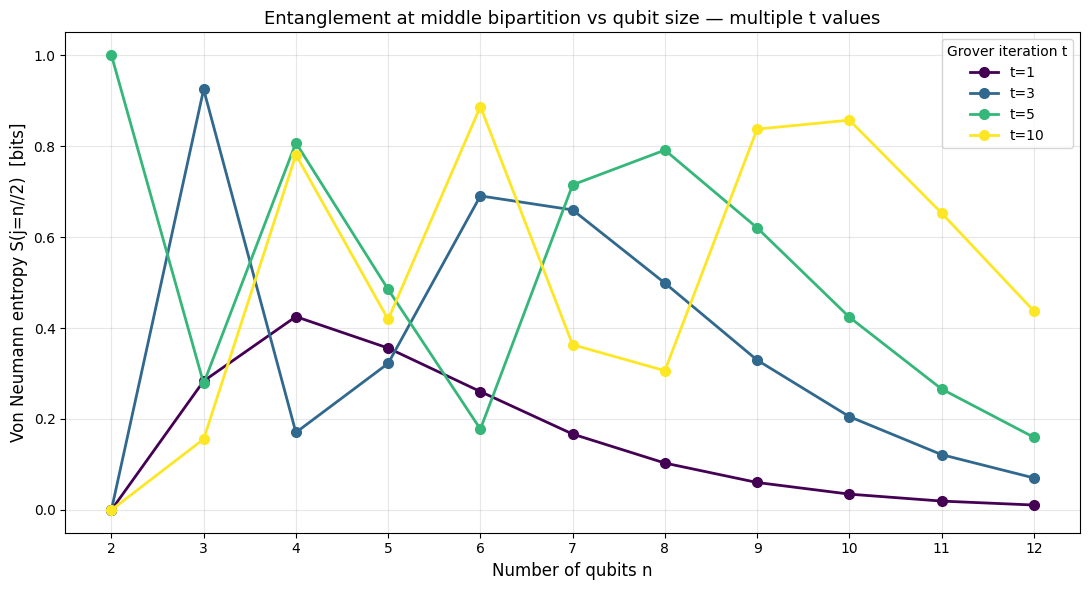

In [9]:
# Multiple t values — build one lambda per t
t_values      = [1, 3, 5, 10]
builder_per_t = [(t, lambda n, t=t: grover.construct_grover(n, t, marked_state))
                 for t in t_values]
entropy.plot_entropy_vs_n_multi_t(qubit_sizes, builder_per_t)

# Grover algorithm MPS analysis

k= 1  sv=0.0369  mps=0.0318  theory=0.0348
k= 2  sv=0.0936  mps=0.0943  theory=0.0946
k= 3  sv=0.1727  mps=0.1783  theory=0.1797
k= 4  sv=0.2907  mps=0.2849  theory=0.2847
k= 5  sv=0.4128  mps=0.4078  theory=0.4032
k= 6  sv=0.5229  mps=0.5312  theory=0.5276
k= 7  sv=0.6502  mps=0.6501  theory=0.6503
k= 8  sv=0.7565  mps=0.7611  theory=0.7637
k= 9  sv=0.8594  mps=0.8556  theory=0.8607
k=10  sv=0.9356  mps=0.9375  theory=0.9352
k=11  sv=0.9828  mps=0.9840  theory=0.9826
k=12  sv=1.0000  mps=0.9999  theory=0.9999
k=13  sv=0.9849  mps=0.9862  theory=0.9862
k=14  sv=0.9388  mps=0.9393  theory=0.9422


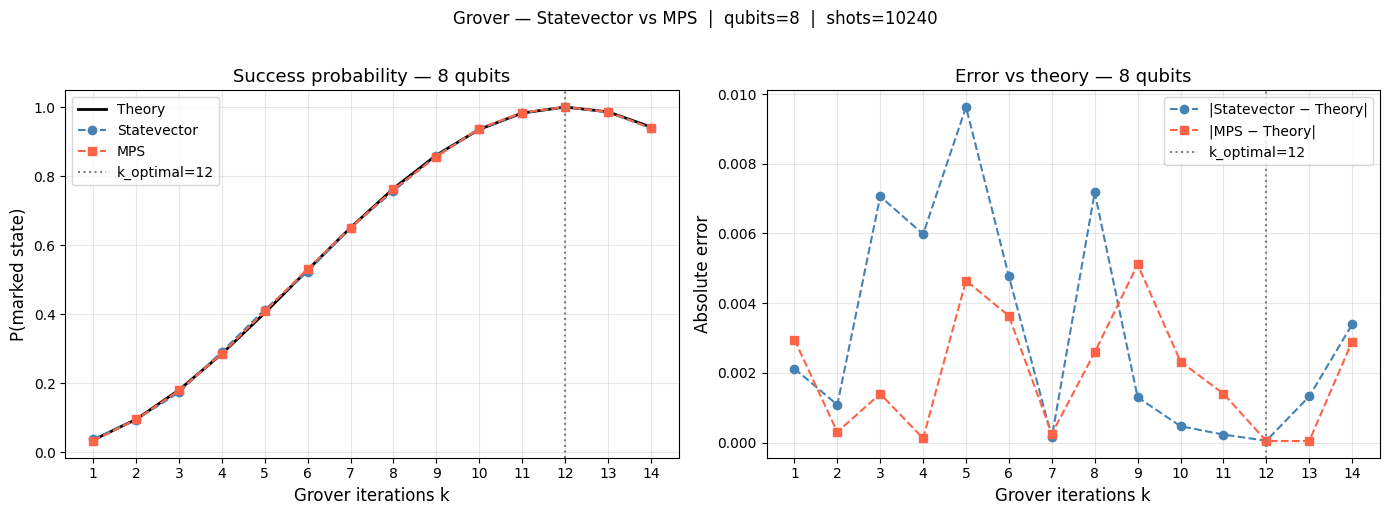

In [10]:
results = mps.run_comparison(
        circuit_builder  = lambda k: grover.construct_grover(qubits, k, marked_state),
        target_bitstring = lambda k: format(marked_state, f"0{qubits}b"),
        k_values         = range(1, k_optimal + 3),
        qubits           = qubits,
        shots            = shots,
        theory_fn        = lambda k: np.sin((2*k + 1) * theta)**2,
        k_optimal        = k_optimal,
        label_x          = "Grover iterations k",
        label_prob       = "P(marked state)",
        title            = "Grover — Statevector vs MPS",
    )

n= 4  sv=    0.006s  mps=0.051s
n= 5  sv=    0.011s  mps=0.052s
n= 6  sv=    0.015s  mps=0.056s
n= 7  sv=    0.019s  mps=0.059s
n= 8  sv=    0.026s  mps=0.073s
n= 9  sv=    0.038s  mps=0.140s
n=10  sv=    0.064s  mps=0.101s
n=11  sv=    0.084s  mps=0.119s
n=12  sv=    0.155s  mps=0.162s
n=13  sv=    0.296s  mps=0.174s
n=14  sv=    0.502s  mps=0.205s
n=15  sv=    0.939s  mps=0.290s
n=16  sv=    2.450s  mps=0.364s
n=17  sv=    6.347s  mps=0.511s
n=18  sv=   18.515s  mps=0.677s
n=19  sv=  120.877s  mps=1.302s
n=20  sv=  286.827s  mps=1.609s
n=21  sv=  601.957s  mps=20.632s
n=22  sv= 1245.551s  mps=104.784s


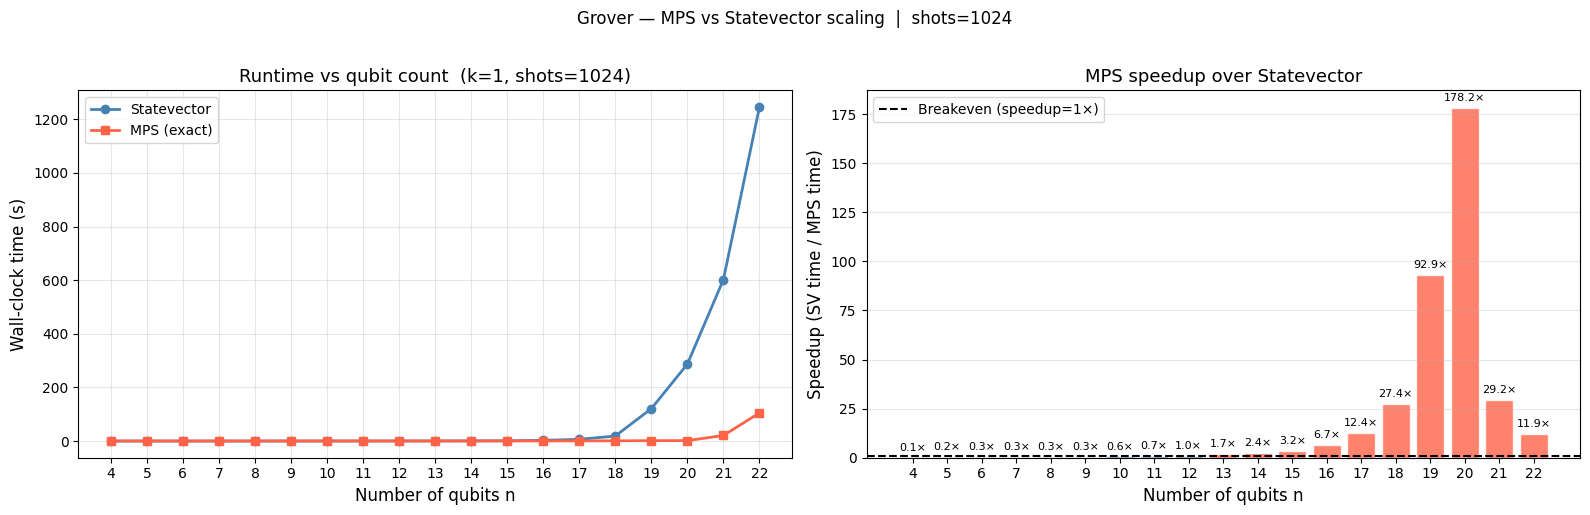

{'sv_times': [0.006414665998818236,
  0.010651042000972666,
  0.01464454199958709,
  0.019066417000431102,
  0.025629792000472662,
  0.03779637499974342,
  0.06389066599876969,
  0.08410662499954924,
  0.15509570900030667,
  0.295621208000739,
  0.502114499999152,
  0.9390307090015995,
  2.4498479169997154,
  6.347439166000186,
  18.514793833999647,
  120.87688187499953,
  286.82733633300086,
  601.9570144999998,
  1245.5508482919995],
 'mps_times': [0.050922415999593795,
  0.051551583001128165,
  0.05610458299997845,
  0.0592144999991433,
  0.07348262500090641,
  0.1397697499996866,
  0.10146420800083433,
  0.11911645899999712,
  0.16217387500000768,
  0.17377445900092425,
  0.20495845900040877,
  0.29016445799970825,
  0.36448987499898067,
  0.5110588750012539,
  0.6768302500004211,
  1.3015544999998383,
  1.60939504199996,
  20.632478499999706,
  104.78367708299993],
 'sv_failed': [False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  Fal

In [10]:
shots       = 1024
k_fixed     = 1
qubit_sizes = list(range(4, 23))

mps.run_scaling_comparison(
    circuit_builder = lambda n: grover.construct_grover(
                            n, k_fixed,
                            0b10101010 & ((1 << n) - 1)   # marked state per n
                        ),
    qubit_sizes     = qubit_sizes,
    k_fixed         = k_fixed,
    shots           = shots,
    title           = "Grover — MPS vs Statevector scaling",
)

In [ ]:
mps.run_memory_comparison(
    circuit_builder = lambda n: grover.construct_grover(
                          n, k_fixed,
                          0b10101010 & ((1 << n) - 1)
                      ),
    qubit_sizes     = qubit_sizes,
    k_fixed         = k_fixed,
    shots           = shots,
    title           = "Grover — MPS vs Statevector memory",
)

# Quantum random walk entropy analysis

In [2]:
shots=1024
qubits = 7
t=50
shots = 1024

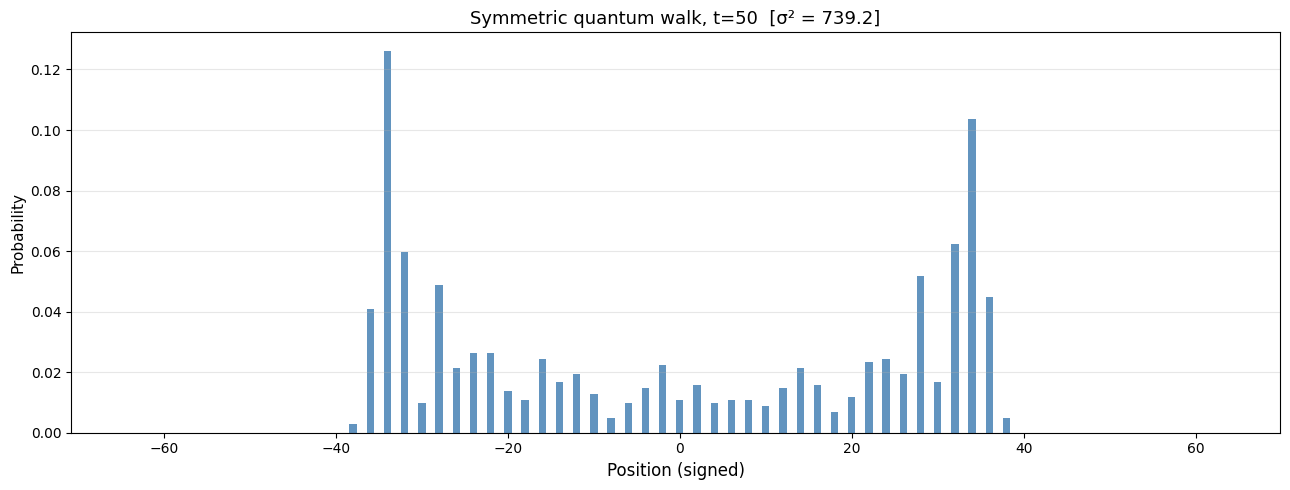

In [3]:
qrw.plot_walk(n_position_qubits=qubits, steps=t, shots = shots)

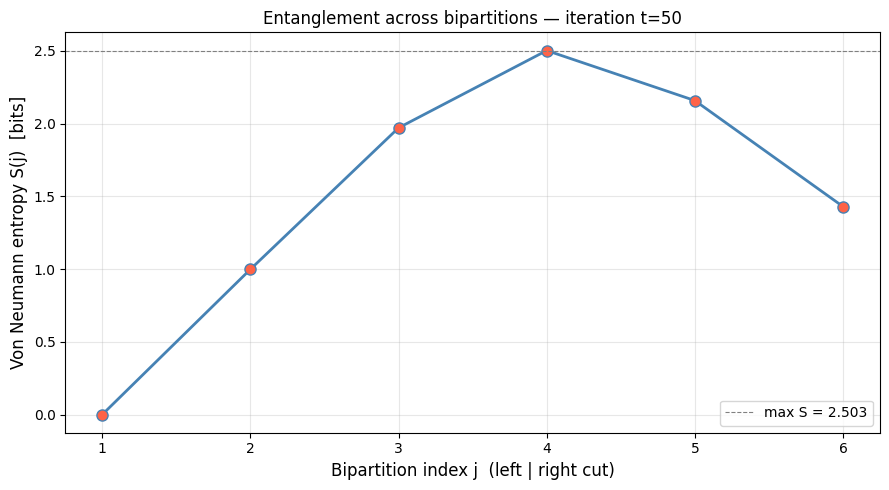

In [4]:
t_fixed = 50
qc = qrw.construct_walk(qubits, t_fixed)
entropy.plot_entropy_vs_j(qc, n=qubits, t= t_fixed)

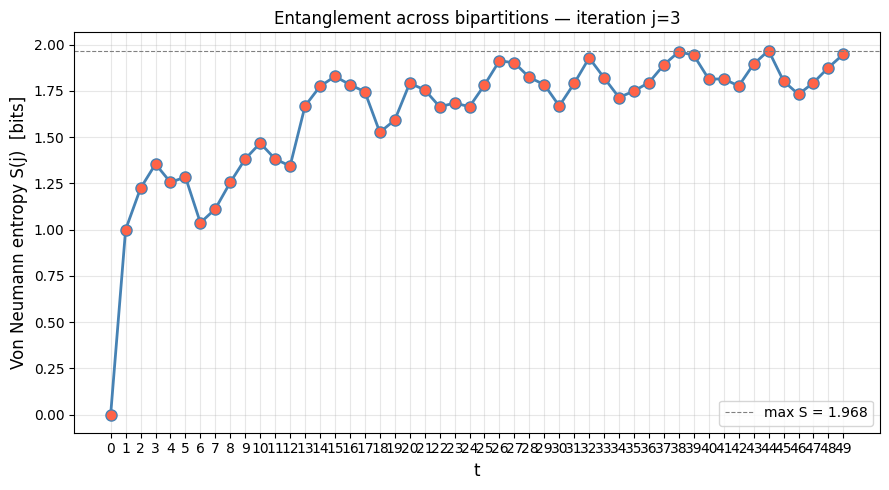

In [5]:
quantum_walk_lambda = lambda t: qrw.construct_walk(qubits, t)
entropy.plot_entropy_vs_t(quantum_walk_lambda, n=qubits, j=qubits // 2, t_max=50)

n= 2  j=1  S=0.00000
n= 3  j=1  S=0.00000
n= 4  j=2  S=0.79885
n= 5  j=2  S=0.79885
n= 6  j=3  S=1.25553
n= 7  j=3  S=1.25553
n= 8  j=4  S=1.27998
n= 9  j=4  S=1.27998
n=10  j=5  S=1.27998
n=11  j=5  S=1.27998
n=12  j=6  S=1.27998


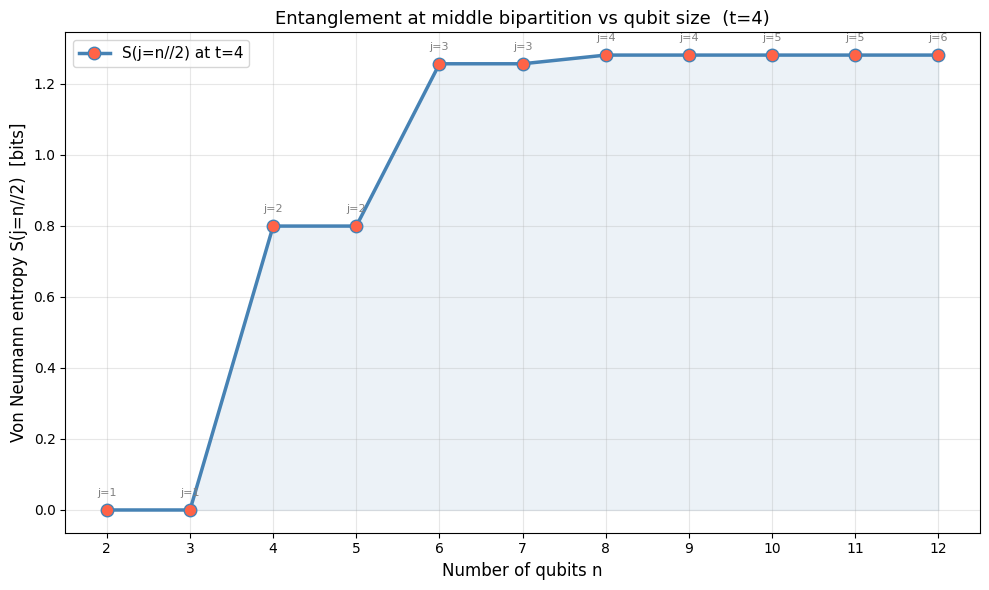

In [6]:
qubit_sizes  = list(range(2, 13))

t_fixed  = 4
builder  = lambda n: qrw.construct_walk(n, t_fixed)
entropy.plot_entropy_vs_n(qubit_sizes, builder, t_fixed)

n= 2  j=1  S=0.00000
n= 3  j=1  S=0.00000
n= 4  j=2  S=1.00000
n= 5  j=2  S=1.00000
n= 6  j=3  S=1.00000
n= 7  j=3  S=1.00000
n= 8  j=4  S=1.00000
n= 9  j=4  S=1.00000
n=10  j=5  S=1.00000
n=11  j=5  S=1.00000
n=12  j=6  S=1.00000
n= 2  j=1  S=0.00000
n= 3  j=1  S=0.00000
n= 4  j=2  S=0.81128
n= 5  j=2  S=0.81128
n= 6  j=3  S=1.35458
n= 7  j=3  S=1.35458
n= 8  j=4  S=1.35458
n= 9  j=4  S=1.35458
n=10  j=5  S=1.35458
n=11  j=5  S=1.35458
n=12  j=6  S=1.35458
n= 2  j=1  S=0.00000
n= 3  j=1  S=0.00000
n= 4  j=2  S=0.98870
n= 5  j=2  S=0.98870
n= 6  j=3  S=1.28461
n= 7  j=3  S=1.28461
n= 8  j=4  S=1.43700
n= 9  j=4  S=1.43700
n=10  j=5  S=1.43700
n=11  j=5  S=1.43700
n=12  j=6  S=1.43700
n= 2  j=1  S=0.00000
n= 3  j=1  S=0.00000
n= 4  j=2  S=0.91282
n= 5  j=2  S=0.90476
n= 6  j=3  S=1.46779
n= 7  j=3  S=1.46779
n= 8  j=4  S=1.44592
n= 9  j=4  S=1.44592
n=10  j=5  S=1.48508
n=11  j=5  S=1.48508
n=12  j=6  S=1.48508
n= 2  j=1  S=0.00000
n= 3  j=1  S=0.00000
n= 4  j=2  S=0.94093
n= 5  j=2  S=

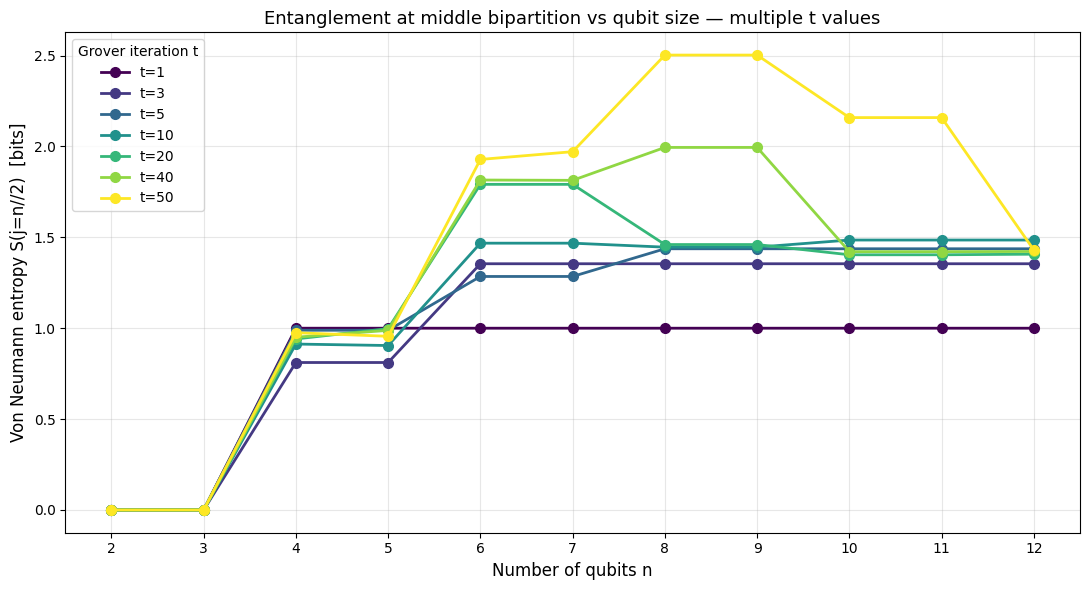

In [7]:
# Multiple t values — build one lambda per t
t_values      = [1, 3, 5, 10,20,40,50]
builder_per_t = [(t, lambda n, t=t: qrw.construct_walk(n, t))
                 for t in t_values]
entropy.plot_entropy_vs_n_multi_t(qubit_sizes, builder_per_t)

# Quantum random walk MPS analysis

n= 4  sv=    0.013s  mps=0.054s
n= 5  sv=    0.029s  mps=0.070s
n= 6  sv=    0.060s  mps=0.098s
n= 7  sv=    0.138s  mps=0.142s
n= 8  sv=    0.236s  mps=0.203s
n= 9  sv=    0.361s  mps=0.313s
n=10  sv=    0.667s  mps=0.491s
n=11  sv=    1.002s  mps=0.662s
n=12  sv=    1.784s  mps=0.925s
n=13  sv=    3.267s  mps=1.228s
n=14  sv=    6.855s  mps=1.605s
n=15  sv=   15.897s  mps=2.112s
n=16  sv=   42.720s  mps=3.325s
n=17  sv=  123.650s  mps=3.997s


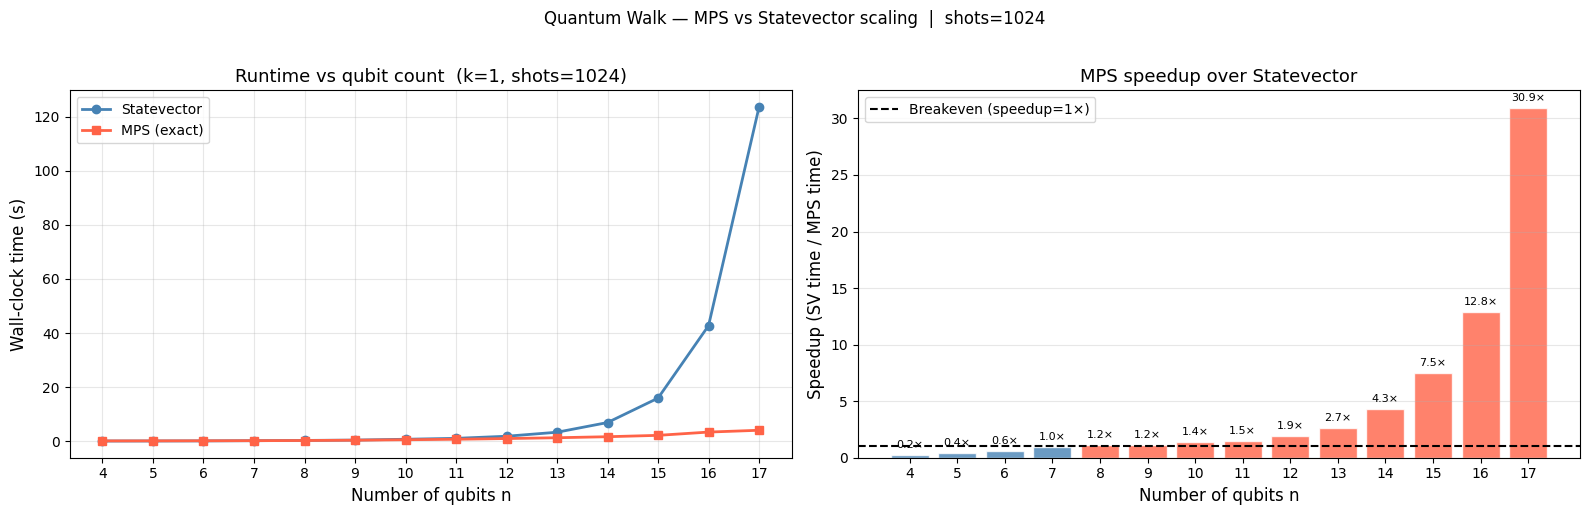

{'sv_times': [0.0127336670011573,
  0.0293522079991817,
  0.05993491700064624,
  0.1376501249978901,
  0.2360804999989341,
  0.3612642920015787,
  0.6673807500010298,
  1.0015262919987435,
  1.7844790829985868,
  3.266675999999279,
  6.85500970800058,
  15.896841833997314,
  42.71972062500208,
  123.65041466700131],
 'mps_times': [0.05418091599858599,
  0.069809583001188,
  0.0983382909980719,
  0.14176745800068602,
  0.20271379200130468,
  0.3128679170004034,
  0.4906760000012582,
  0.6620965000001888,
  0.9246527920004155,
  1.2276241250001476,
  1.6047772080019058,
  2.1121896660006314,
  3.3250587500006077,
  3.996685666999838],
 'sv_failed': [False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False],
 'qubit_sizes': [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]}

In [12]:
shots       = 1024
k_fixed     = 1
qubit_sizes = list(range(4, 18))

mps.run_scaling_comparison(
    circuit_builder = lambda n: qrw.construct_walk_no_measure(n, k_fixed),
    qubit_sizes     = qubit_sizes,
    k_fixed         = k_fixed,
    shots           = shots,
    title           = "Quantum Walk — MPS vs Statevector scaling",
)

# Quantum Fourier transform entropy analysis

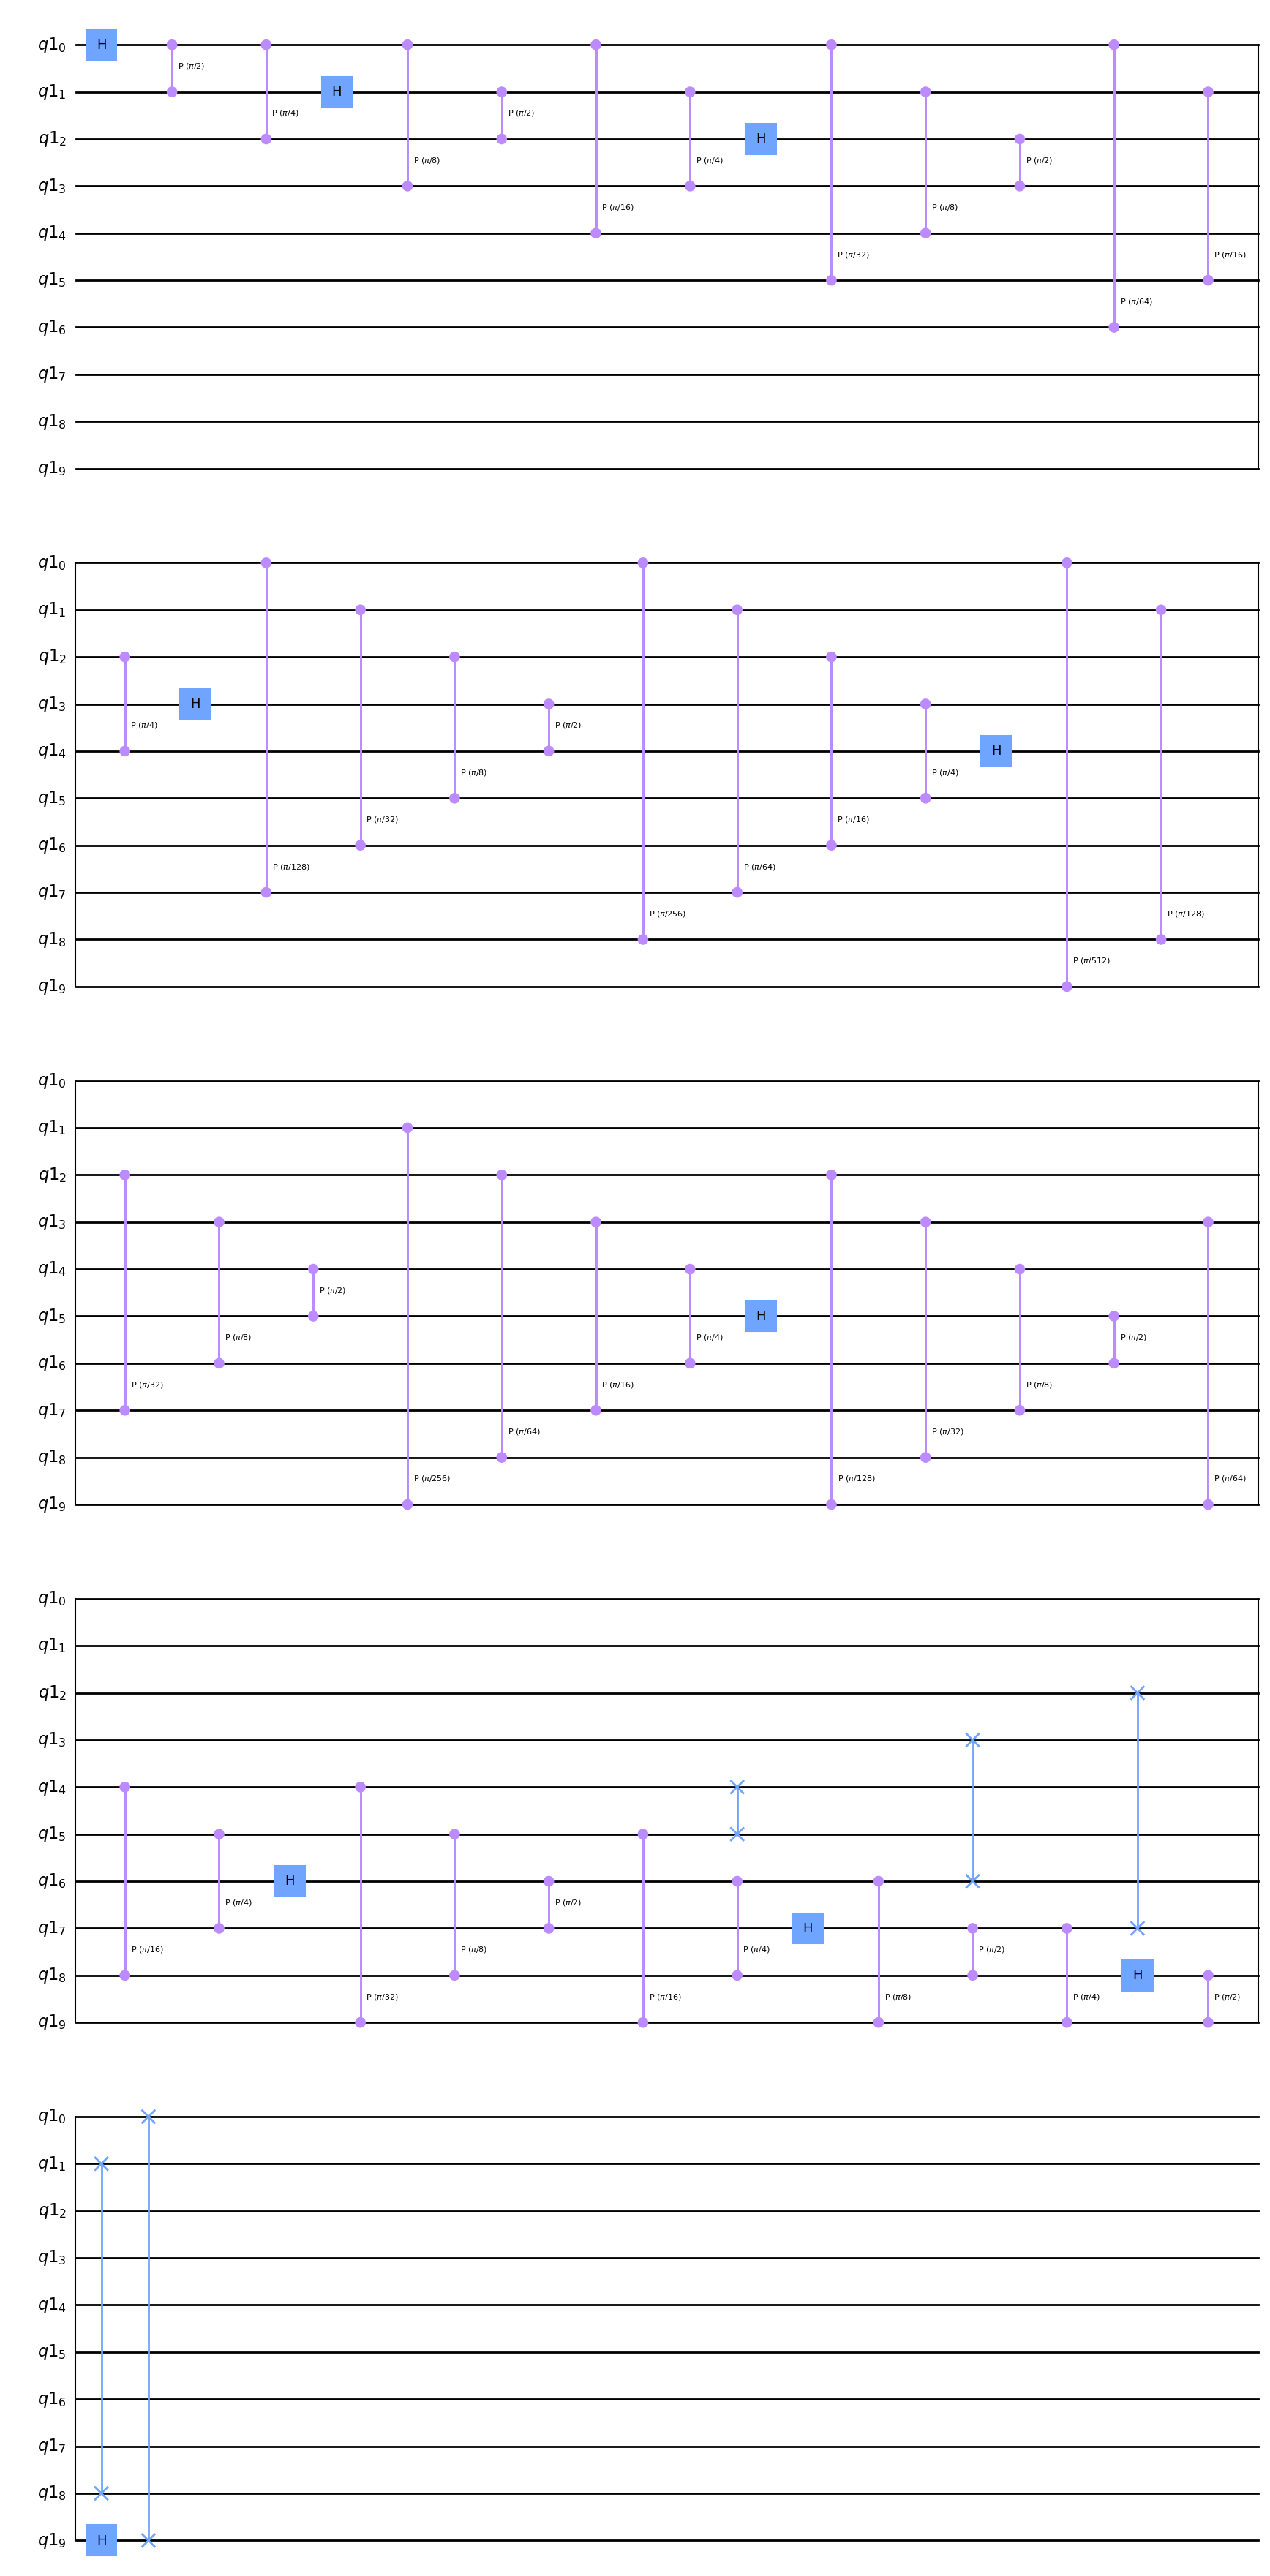

In [ ]:
n = 10
t = 10

qc = qft.qft(n, t)

qc.draw(output="mpl", style="clifford")


# Quantum Fourier transform MPS analysis

k= 1  sv=0.2484  mps=0.2554
k= 2  sv=0.1275  mps=0.1300
k= 3  sv=0.0605  mps=0.0645
k= 4  sv=0.0317  mps=0.0310
k= 5  sv=0.0144  mps=0.0140
k= 6  sv=0.0070  mps=0.0084
k= 7  sv=0.0077  mps=0.0073


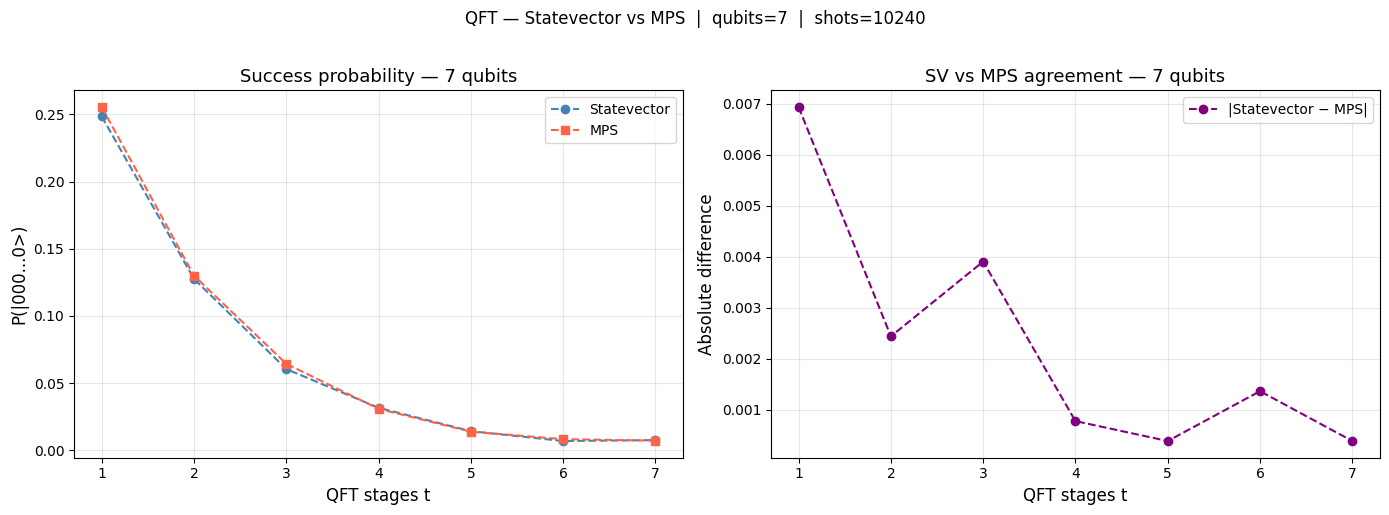

In [3]:
import importlib
import mps
importlib.reload(mps)

# step 2 — run comparison
from qft import qft
import numpy as np

n     = 7
t_max = n
shots = 10240

results = mps.run_comparison(
    circuit_builder  = lambda t: qft(n, t),
    target_bitstring = lambda t: "0" * n,
    k_values         = range(1, t_max + 1),
    qubits           = n,
    shots            = shots,
    theory_fn        = None,
    k_optimal        = None,
    label_x          = "QFT stages t",
    label_prob       = "P(|000...0>)",
    title            = "QFT — Statevector vs MPS",
)

n= 4  sv=    0.006s  mps=0.041s
n= 5  sv=    0.004s  mps=0.038s
n= 6  sv=    0.004s  mps=0.040s
n= 7  sv=    0.004s  mps=0.038s
n= 8  sv=    0.005s  mps=0.039s
n= 9  sv=    0.006s  mps=0.049s
n=10  sv=    0.008s  mps=0.042s
n=11  sv=    0.011s  mps=0.040s
n=12  sv=    0.019s  mps=0.040s
n=13  sv=    0.038s  mps=0.046s
n=14  sv=    0.094s  mps=0.054s
n=15  sv=    0.261s  mps=0.052s
n=16  sv=    0.494s  mps=0.044s
n=17  sv=    0.937s  mps=0.043s
n=18  sv=    2.456s  mps=0.043s
n=19  sv=    5.265s  mps=0.046s
n=20  sv=   13.120s  mps=0.047s
n=21  sv=   33.433s  mps=0.057s
n=22  sv=   77.917s  mps=0.050s


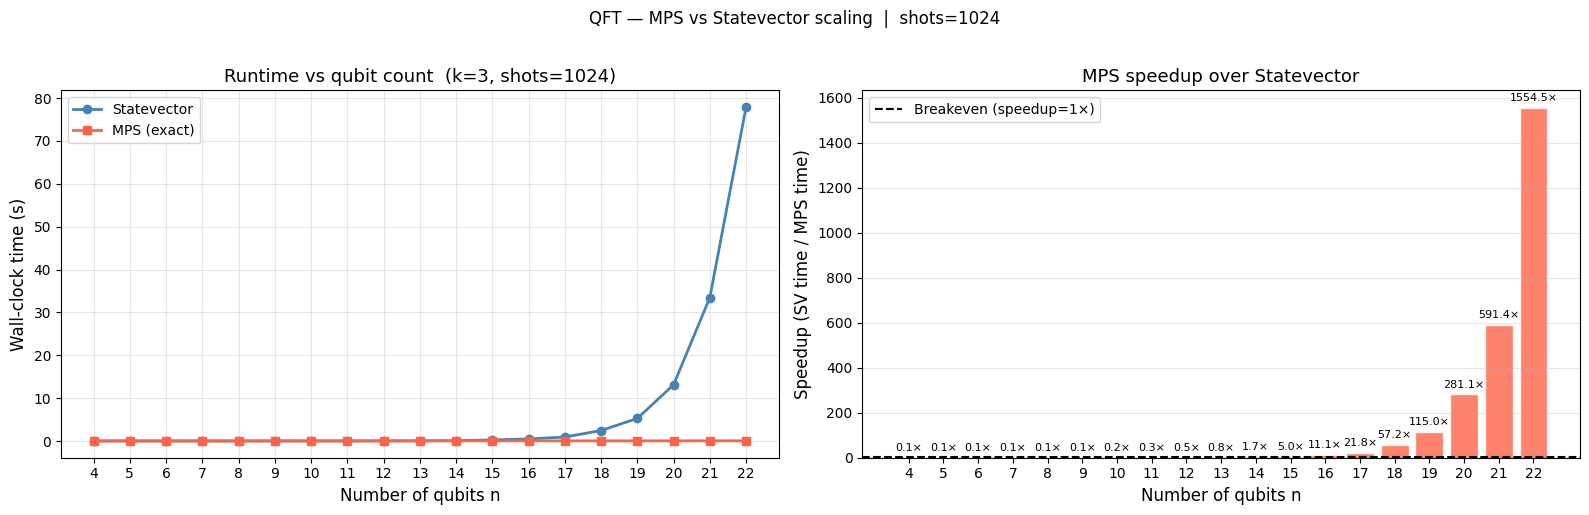

{'sv_times': [0.006002583002555184,
  0.003659707999759121,
  0.0037905829994997475,
  0.004156292001425754,
  0.00476741599777597,
  0.005592083998635644,
  0.008287500000733417,
  0.011104749999503838,
  0.018996333001268795,
  0.0384857919998467,
  0.09354437500223867,
  0.26129191699874355,
  0.4937705839984119,
  0.9365352499989967,
  2.4560213750010007,
  5.2652506249978615,
  13.120230042000912,
  33.432967791999545,
  77.9166736670013],
 'mps_times': [0.0408373330028553,
  0.03818912499991711,
  0.03969879099895479,
  0.03803691599750891,
  0.039486082998337224,
  0.049107208997156704,
  0.04233237500011455,
  0.03973691699866322,
  0.04005025000151363,
  0.046305457999551436,
  0.05440337500112946,
  0.051967333998618415,
  0.044292667000263464,
  0.04304716700062272,
  0.0429748330025177,
  0.04577008400156046,
  0.04667650000192225,
  0.056534625000495,
  0.05012233300294611],
 'sv_failed': [False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  Fal

In [5]:
shots       = 1024
t_fixed     = 3       # fix number of QFT stages
qubit_sizes = list(range(4, 23))

mps.run_scaling_comparison(
    circuit_builder = lambda n: qft(n, t_fixed),
    qubit_sizes     = qubit_sizes,
    k_fixed         = t_fixed,
    shots           = shots,
    title           = "QFT — MPS vs Statevector scaling",
)

n= 4  sv=      0.15MB  mps=0.11MB
n= 5  sv=      0.16MB  mps=0.11MB
n= 6  sv=      0.18MB  mps=0.11MB
n= 7  sv=      0.25MB  mps=0.11MB
n= 8  sv=      0.52MB  mps=0.11MB
n= 9  sv=      1.14MB  mps=0.11MB
n=10  sv=      2.52MB  mps=0.11MB
n=11  sv=      5.52MB  mps=0.11MB
n=12  sv=     12.02MB  mps=0.11MB
n=13  sv=     26.04MB  mps=0.11MB
n=14  sv=     56.10MB  mps=0.11MB
n=15  sv=    120.29MB  mps=0.11MB
n=16  sv=    256.79MB  mps=0.11MB
n=17  sv=    546.04MB  mps=0.11MB
n=18  sv=   1157.05MB  mps=0.11MB
n=19  sv=   2444.05MB  mps=0.11MB
n=20  sv=   5148.07MB  mps=0.11MB


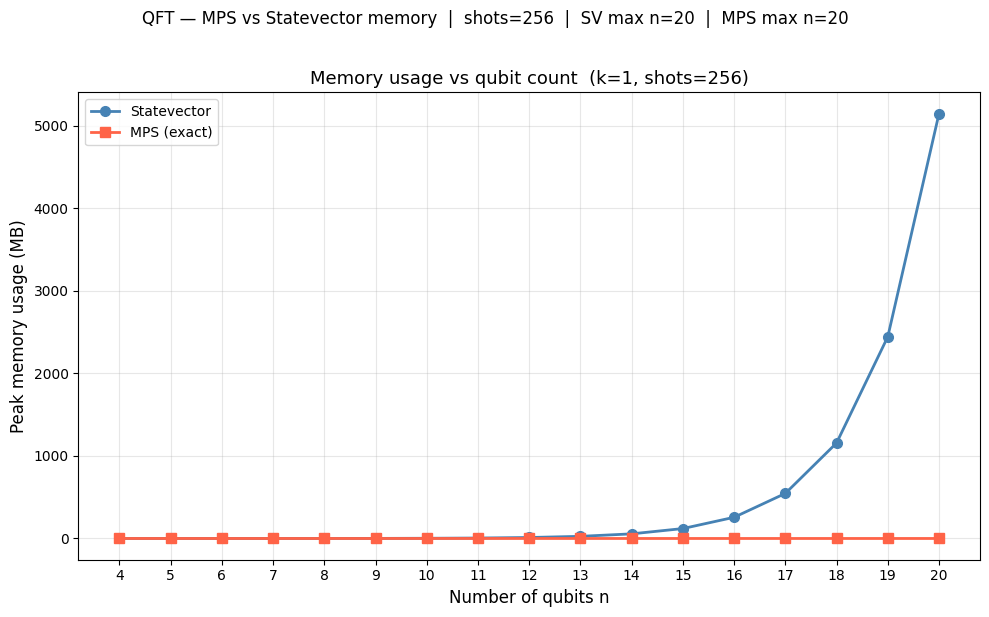

{'sv_memory': [0.1460704803466797,
  0.16324424743652344,
  0.1849985122680664,
  0.24660110473632812,
  0.5189580917358398,
  1.1440277099609375,
  2.516622543334961,
  5.515898704528809,
  12.017622947692871,
  26.035971641540527,
  56.10005187988281,
  120.2893590927124,
  256.7915735244751,
  546.0431051254272,
  1157.0462608337402,
  2444.047469139099,
  5148.073104858398],
 'mps_memory': [0.11263084411621094,
  0.10690593719482422,
  0.11047554016113281,
  0.10708236694335938,
  0.10814285278320312,
  0.11011600494384766,
  0.11031723022460938,
  0.10925865173339844,
  0.11040973663330078,
  0.1076507568359375,
  0.1071329116821289,
  0.10782623291015625,
  0.10640525817871094,
  0.1059732437133789,
  0.10581398010253906,
  0.10586357116699219,
  0.10600757598876953],
 'sv_failed': [False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False],
 'qubit_sizes': [4, 5, 6, 7, 8, 9, 10, 11, 12, 1

In [4]:
shots       = 256
k_fixed     = 1
qubit_sizes = list(range(4, 21))

mps.run_memory_comparison(
    circuit_builder = lambda n: qft(n, k_fixed),
    qubit_sizes     = qubit_sizes,
    k_fixed         = k_fixed,
    shots           = shots,
    title           = "QFT — MPS vs Statevector memory",
)